In [1]:
import pandas as pd

# Load the original dataset
file_path = "../data/Online Retail.xlsx"

df = pd.read_excel(file_path)

# Display the first 5 rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
# Basic dataset information

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 541909
Number of columns: 8

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


In [3]:
# Basic dataset information

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 541909
Number of columns: 8

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


In [4]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5268


In [5]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

Missing values by column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
# Check cancelled invoices

cancelled_orders = df["InvoiceNo"].astype(str).str.startswith("C")

print("Cancelled transactions:", cancelled_orders.sum())
print("Normal transactions:", (~cancelled_orders).sum())

Cancelled transactions: 9288
Normal transactions: 532621


In [8]:
# Check unusual quantities and prices

print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())

Quantity <= 0: 10624
UnitPrice <= 0: 2517


In [7]:
# Check cancelled invoices

cancelled_orders = df["InvoiceNo"].astype(str).str.startswith("C")

print("Cancelled transactions:", cancelled_orders.sum())
print("Normal transactions:", (~cancelled_orders).sum())

Cancelled transactions: 9288
Normal transactions: 532621


In [9]:
# Create a cleaned sales dataset

cleaned_df = df.copy()

# Remove cancelled invoices
cleaned_df = cleaned_df[
    ~cleaned_df["InvoiceNo"].astype(str).str.startswith("C")
]

# Remove invalid quantities and prices
cleaned_df = cleaned_df[
    (cleaned_df["Quantity"] > 0) &
    (cleaned_df["UnitPrice"] > 0)
]

# Remove exact duplicate transactions
cleaned_df = cleaned_df.drop_duplicates()

print("Original rows:", len(df))
print("Cleaned rows:", len(cleaned_df))
print("Rows removed:", len(df) - len(cleaned_df))

Original rows: 541909
Cleaned rows: 524878
Rows removed: 17031


In [10]:
# Create revenue for each transaction

cleaned_df["Revenue"] = (
    cleaned_df["Quantity"] * cleaned_df["UnitPrice"]
)

print("Total Revenue: £{:,.2f}".format(cleaned_df["Revenue"].sum()))

Total Revenue: £10,642,110.80


In [11]:
# Basic business metrics

total_orders = cleaned_df["InvoiceNo"].nunique()
total_products = cleaned_df["StockCode"].nunique()
total_customers = cleaned_df["CustomerID"].nunique()
total_countries = cleaned_df["Country"].nunique()

average_order_value = (
    cleaned_df.groupby("InvoiceNo")["Revenue"].sum().mean()
)

print(f"Total Orders: {total_orders:,}")
print(f"Total Products: {total_products:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Countries Served: {total_countries:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

Total Orders: 19,960
Total Products: 3,922
Total Customers: 4,338
Countries Served: 38
Average Order Value: £533.17


In [12]:
# Transaction date range

print("First transaction:",cleaned_df["InvoiceDate"].min())
print("Last transaction:",cleaned_df["InvoiceDate"].max())

First transaction: 2010-12-01 08:26:00
Last transaction: 2011-12-09 12:50:00


In [13]:
# Save the cleaned dataset

output_path = "../data/cleaned_retail.csv"

cleaned_df.to_csv(output_path,index=False)

print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: ../data/cleaned_retail.csv


In [14]:
# Monthly revenue analysis

cleaned_df["YearMonth"] = cleaned_df["InvoiceDate"].dt.to_period("M")

monthly_revenue = (
    cleaned_df.groupby("YearMonth")["Revenue"]
    .sum()
    .sort_index()
)

monthly_revenue

YearMonth
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: Revenue, dtype: float64

In [15]:
# Top 10 products by revenue

top_products = (
    cleaned_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [16]:
# Revenue by country

country_revenue = (
    cleaned_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

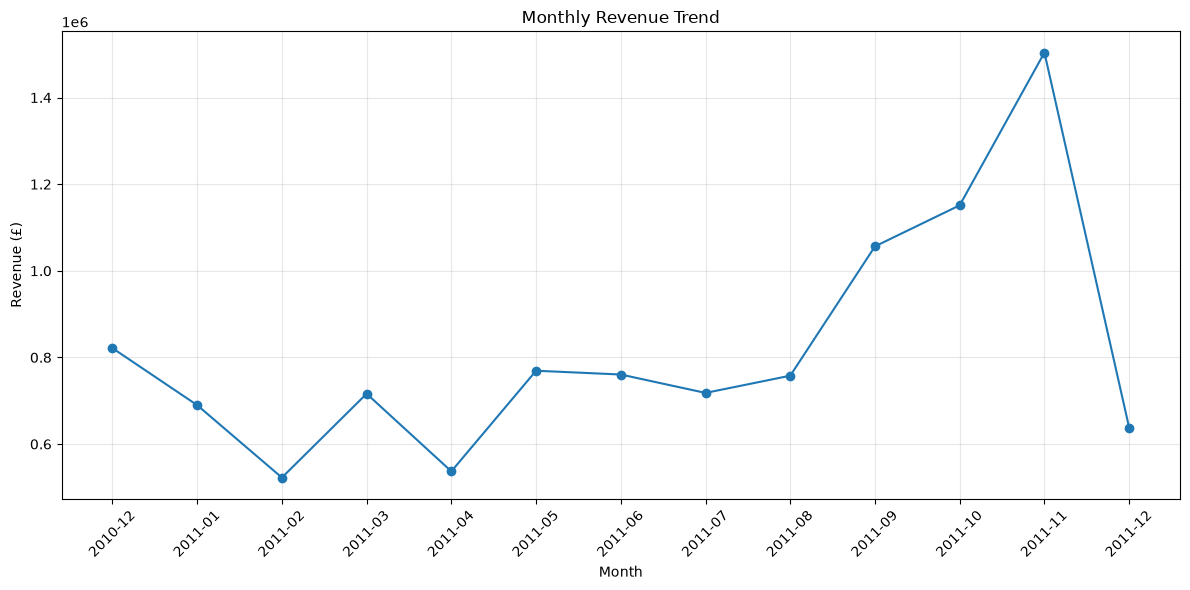

In [17]:
import matplotlib.pyplot as plt

# Monthly revenue chart

monthly_revenue_plot = monthly_revenue.copy()
monthly_revenue_plot.index = monthly_revenue_plot.index.astype(str)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue_plot.index,
    monthly_revenue_plot.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(True,alpha=0.3)
plt.tight_layout()

plt.show()

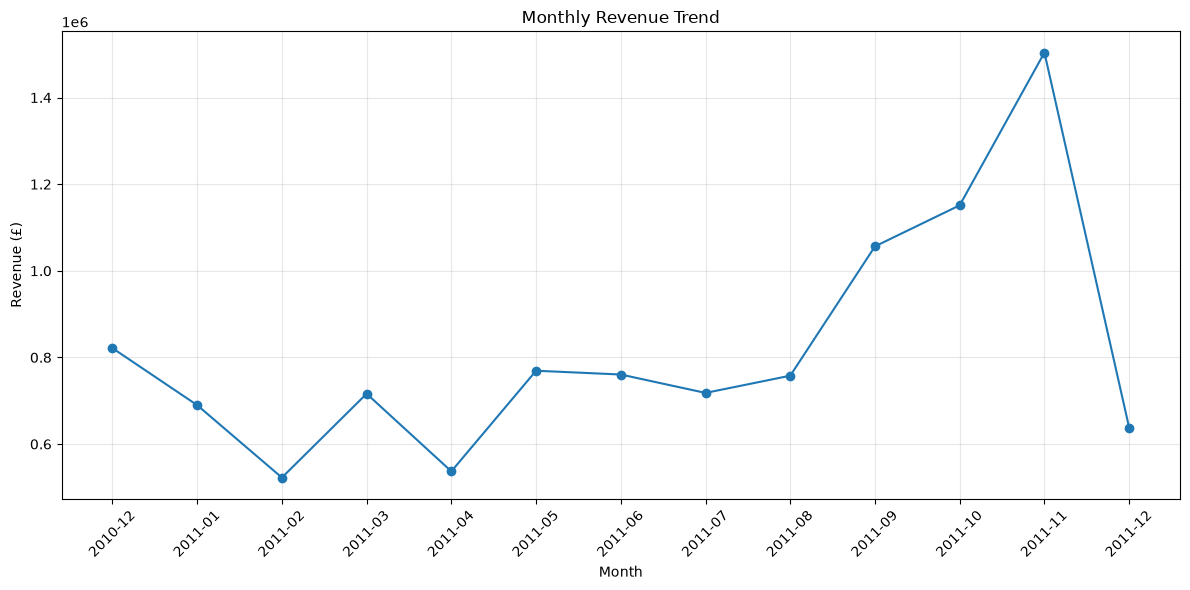

In [18]:
# Save monthly revenue chart

plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue_plot.index,
    monthly_revenue_plot.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(True,alpha=0.3)
plt.tight_layout()

plt.savefig("../images/monthly_revenue_trend.png",dpi=300,bbox_inches="tight")

plt.show()

In [19]:
# Top 10 customers by revenue

customer_revenue = (
    cleaned_df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

customer_revenue

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [20]:
# Top 10 customers by number of orders

customer_orders = (
    cleaned_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

customer_orders

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

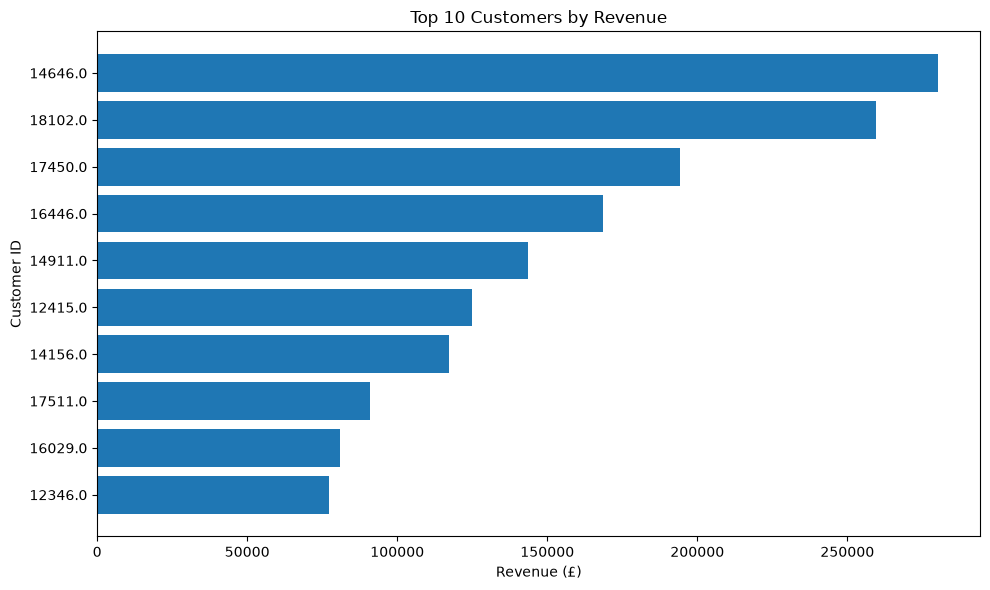

In [21]:
import matplotlib.pyplot as plt

# Top 10 customers by revenue

customer_revenue_plot = customer_revenue.sort_values(ascending=True)

plt.figure(figsize=(10,6))

plt.barh(
    customer_revenue_plot.index.astype(str),
    customer_revenue_plot.values
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")
plt.tight_layout()

plt.savefig(
    "../images/top_customers_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

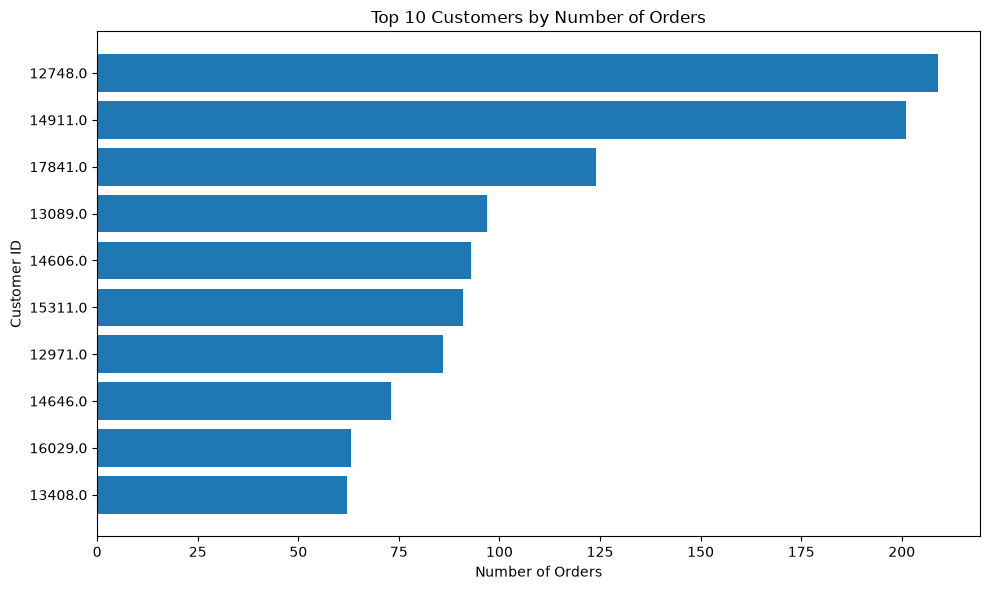

In [22]:
# Top 10 customers by number of orders

customer_orders_plot = customer_orders.sort_values(ascending=True)

plt.figure(figsize=(10,6))

plt.barh(
    customer_orders_plot.index.astype(str),
    customer_orders_plot.values
)

plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Customer ID")
plt.tight_layout()

plt.savefig(
    "../images/top_customers_by_orders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
# Customer purchase frequency

customer_order_frequency = (
    cleaned_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

repeat_customers = customer_order_frequency[
    customer_order_frequency > 1
]

one_time_customers = customer_order_frequency[
    customer_order_frequency == 1
]

print("Total identified customers:",len(customer_order_frequency))
print("Repeat customers:",len(repeat_customers))
print("One-time customers:",len(one_time_customers))

repeat_rate = (
    len(repeat_customers) / len(customer_order_frequency)
) * 100

print(f"Repeat customer rate: {repeat_rate:.2f}%")

Total identified customers: 4338
Repeat customers: 2845
One-time customers: 1493
Repeat customer rate: 65.58%


In [24]:
# RFM Customer Segmentation

import pandas as pd

# Use the day after the last transaction as the analysis reference date
reference_date = cleaned_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = cleaned_df.dropna(subset=["CustomerID"]).groupby("CustomerID").agg(
    Recency=("InvoiceDate",lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo","nunique"),
    Monetary=("Revenue","sum")
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [25]:
# Assign scores from 1 to 4

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4,3,2,1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    4,
    labels=[1,2,3,4]
).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,1,77183.60,1,1,4,114
1,12347.0,2,7,4310.00,4,4,4,444
2,12348.0,75,4,1797.24,2,3,4,234
3,12349.0,19,1,1757.55,3,1,4,314
4,12350.0,310,1,334.40,1,1,2,112


In [26]:
# Create customer segments

def segment_customer(row):
    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    if r >= 3 and f >= 3 and m >= 3:
        return "Champions"
    elif r >= 3 and f >= 2:
        return "Loyal Customers"
    elif r >= 3 and f <= 2:
        return "New / Promising"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2 and m >= 3:
        return "High Value At Risk"
    else:
        return "Other"

rfm["Segment"] = rfm.apply(segment_customer,axis=1)

rfm["Segment"].value_counts()

Segment
Champions             1317
Other                 1238
At Risk                646
Loyal Customers        612
High Value At Risk     266
New / Promising        259
Name: count, dtype: int64

In [27]:
# Save RFM customer segmentation

rfm.to_csv(
    "../data/customer_rfm_segments.csv",
    index=False
)

print("RFM segmentation saved successfully.")

RFM segmentation saved successfully.


In [28]:
rfm["Segment"].value_counts()


Segment
Champions             1317
Other                 1238
At Risk                646
Loyal Customers        612
High Value At Risk     266
New / Promising        259
Name: count, dtype: int64

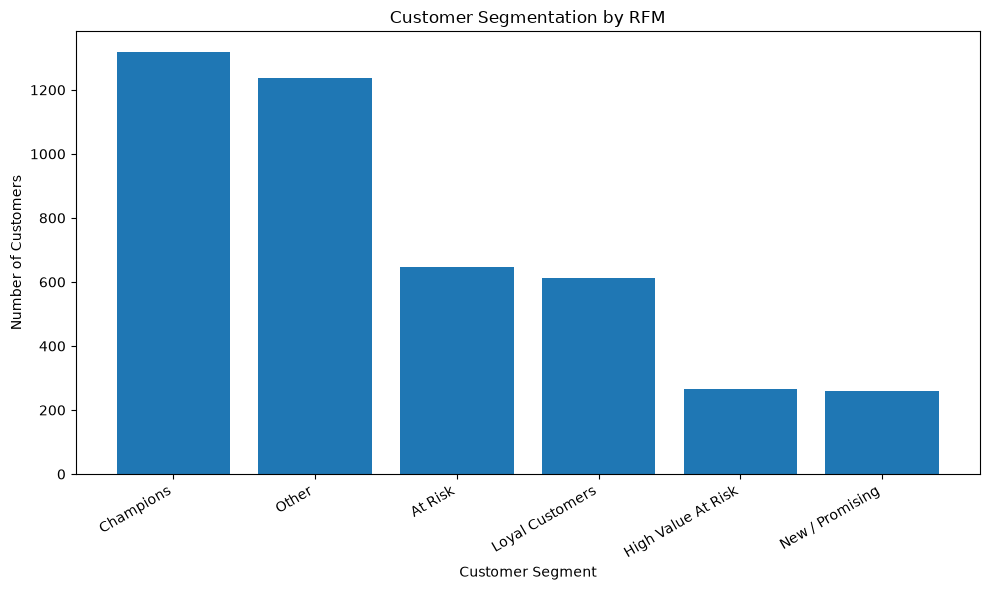

In [29]:
import matplotlib.pyplot as plt

# Customer segment distribution

segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(10,6))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title("Customer Segmentation by RFM")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30,ha="right")

plt.tight_layout()

plt.savefig(
    "../images/customer_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# Revenue contribution by customer segment

segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

Segment
Champions             6488695.171
At Risk               1038214.361
Loyal Customers        503475.730
High Value At Risk     414289.671
Other                  350970.391
New / Promising         91563.570
Name: Monetary, dtype: float64

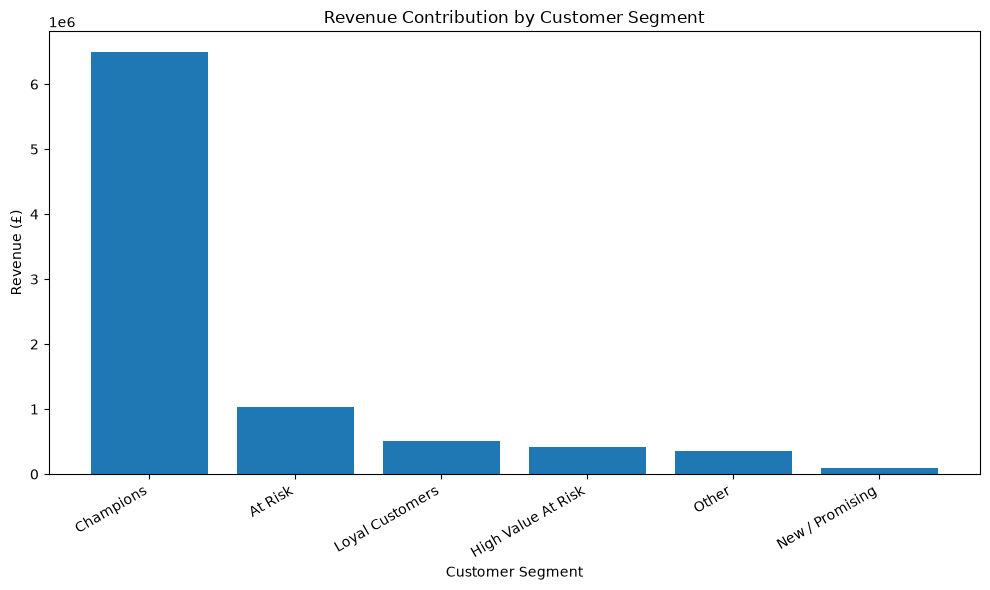

In [31]:
plt.figure(figsize=(10,6))

plt.bar(
    segment_revenue.index,
    segment_revenue.values
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=30,ha="right")

plt.tight_layout()

plt.savefig(
    "../images/revenue_by_customer_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
# Save segment revenue summary

segment_summary = pd.DataFrame({
    "Customer_Count": segment_counts,
    "Total_Revenue": segment_revenue
}).fillna(0)

segment_summary.to_csv(
    "../data/customer_segment_summary.csv"
)

print("Customer segment summary saved successfully.")

Customer segment summary saved successfully.
